# Quantum Arithmetic

In this tutorial, we will learn about using quantum arithmetic in Workbench.

As we discussed in the [previous tutorial](./Quantum-Arithmetic-Data-Types.ipynb), quantum algorithms often involve performing arithmetic computations on superpositions of numeric values. 
The same tutorial introduced quantum data types that represent numeric data types. In this tutorial, we will discuss the basic quantum arithmetic operations Workbench offers for working with these data types.

## Design principles of quantum arithmetic primitives

Workbench implements all quantum arithmetic operations as [Qubricks](./Qubricks.ipynb). It defines alternative syntax ("syntactic sugar") for the most commonly used ones, but under the hood using a quantum arithmetic operation follows the same pattern:

1. Create an instance of the corresponding Qubrick. Some arithmetic operations have several implementations; in this case, you have to choose which one to use.
2. Call the `compute` method of this Qubrick instance with the appropriate arguments. Most arithmetic operations are implemented to handle multiple quantum arithmetic data types or a mix of quantum and classical data types. Comparators are the exception to this rule; currently they support only unsigned integers (quantum and classical).
3. Handling the results of the arithmetic operation depends on whether it is done in-place or out-of-place. In-place operations modify one of the quantum arguments to store the results. Out-of-place operations either take the result register as one of the arguments or allocate a fresh register that you then retrieve using the `get_result_qreg` method (you can read more about handling auxiliary qubits in [this tutorial](./Qubricks-Qubit-Management.ipynb)).

You will see examples of using this pattern in Workbench programs throughout this tutorial as we go through each type of arithmetic operations.

> In this tutorial, we use state vector simulator to run the examples, since they are very small. Remember, if you want to test quantum arithmetic on bigger circuits than state vector simulator can handle, you can use bit-vector simulator! [Simulating Workbench Programs tutorial](./Simulating-WB-Programs.ipynb) includes an example of simulating adding an integer to a 1,000-qubit register, and that's not the limit!


## Addition

Quantum addition is the operation of adding two compatible numbers. Three main built-in Workbench adders, naive adder (`NaiveAdd` Qubrick), Gidney adder (`GidneyAdd` Qubrick) and Cuccaro adders (`CuccaroAdd` Qubrick, `CuccaroDepthOptimisedAdd` Qubrick), are designed to operate on a variety of data types, including all quantum arithmetic data types and classical numbers.

### In-place addition

To perform in-place addition using one of these adders, you instantiate the corresponding Qubrick and call its `compute` method with two arguments that specify the numbers being added. The first argument is the destination register - the register which will be modified to store the sum; it must be a quantum arithmetic data type. The second register can be quantum or classical.

Workbench provides "syntactic sugar" for naive implementations of arithmetic operations - convenient syntax that makes using them more concise and readable. For in-place addition, `reg1 += reg2` replaces instantiating `NaiveAdd` Qubrick and calling `compute(reg1, reg1)` for it.

The following code snippet allocates and initializes two `QUInt` registers and uses three adders, first naive adder, then Gidney adder and then Cuccaro adder, to add the second register to the first one. 

> Note that addition is modular: if the sum doesn't fit in the destination register, the carry-out bit is discarded. In this example, during the second addition ($7+3$) the register `reg1` is too small to hold the addition result ($10$) and ends up storing $7 + 3 \text{ mod } 8 = 2$ instead. Then in the final example we are left with $ 2 + 3 \text{ mod } 8 = 5$.  If you want to prevent overflows, you need to make sure your destination register is large enough to store the entire sum.

4 + 3 = 7
7 + 3 = 2 (mod 8)
2 + 3 = 5 (mod 8)


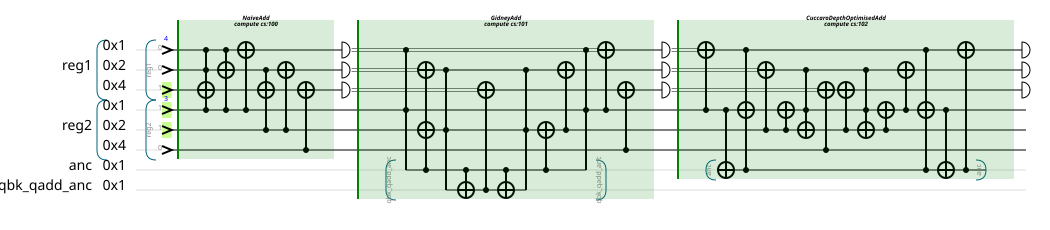

In [1]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import CuccaroDepthOptimisedAdd, GidneyAdd, NaiveAdd

qpu = QPU(num_qubits=8)
reg1, reg2 = QUInt(3, "reg1", qpu), QUInt(3, "reg2", qpu)

reg1.write(4)
reg2.write(3)

# Use naive adder to add two unsigned integers in-place
reg1 += reg2
# The line above is equivalent to the following two lines:
# naive_add = NaiveAdd()
# naive_add.compute(reg1, reg2)

print(f"4 + 3 = {reg1.read()}")

# Use Gidney adder to add two unsigned integers in-place
gidney_add = GidneyAdd()
gidney_add.compute(reg1, reg2)

print(f"7 + 3 = {reg1.read()} (mod 8)")

# Use Cuccaro adder to add two unsigned integers in-place
cuccaro_add = CuccaroDepthOptimisedAdd()
cuccaro_add.compute(reg1, reg2)

print(f"2 + 3 = {reg1.read()} (mod 8)")

qpu.draw(show_qubricks=True)

Naive adder, Gidney adder and Cuccaro adders have identical syntax and can be used interchangeably in the code, but they use different implementations. Naive adder doesn't use auxiliary qubits, which makes it better for programs running on a state vector simulator. Gidney adder is more gate-efficient but uses auxiliary qubits. The Cuccaro adders are a middle ground using only 1 auxiliary qubit with a modest overhead in gate count.
In the later demos in this tutorial, we will lean towards using the naive adder, since its distinctive gate structure makes the behaviors we'll be discussing easier to see in circuit diagrams.

### Increment by a classical number

The next example demonstrates using the same two adders to increment a quantum number by a constant. You can see that the syntax is the same, the only difference is the type of the second argument of the `compute` method. Under the hood, the adder Qubrick analyzes the type of the second argument and chooses the appropriate implementation. 

> In the case of the naive adder, addition is implemented using sequences of controlled gates, with exactly one control qubit of each gate belonging to the second register. If the second addend is a classical number, the classical control bits are analyzed on the fly, and each gate is added to the circuit only if the classical control bit is $1$, otherwise it is skipped. If you compare the circuits produced by `NaiveAdd` in this example and in the previous one, you'll see that the last part of the circuit - the gate controlled on the most significant bit of the second register - is skipped when the second addend is a classical value. Indeed, the most significant bit of a three-bit notation of unsigned integer $3$ is $0$, and there is no need to use it to increment the sum.

4 + 3 = 7
7 + 3 = 2 (mod 8)


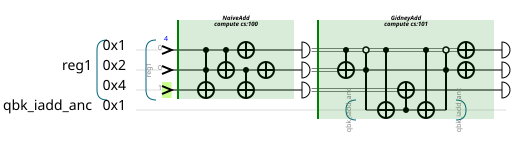

In [2]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import GidneyAdd, NaiveAdd

qpu = QPU(num_qubits=4)
reg1 = QUInt(3, "reg1", qpu)

reg1.write(4)
const = 3

# Use naive adder to add a constant to an unsigned integer in-place
reg1 += const
# The line above is equivalent to the following two lines:
# naive_add = NaiveAdd()
# naive_add.compute(reg1, const)

print(f"4 + 3 = {reg1.read()}")

# Use Gidney adder to add a constant to an unsigned integer in-place
gidney_add = GidneyAdd()
gidney_add.compute(reg1, const)

print(f"7 + 3 = {reg1.read()} (mod 8)")

qpu.draw(show_qubricks=True)

### Out-of-place addition

These adders can also perform addition out-of-place. To do this, they allocate the result register of size that matches the size of the largest addends and use it as the destination of addition. Same as in-place addition, out-of-place addition is modular.

The following example shows out-of-place addition of two `QUInt` registers using the naive adder. (There is no syntactic sugar for this operation, so you have to instantiate `NaiveAdd` Qubrick explicitly.) 

> Notice that the first step of out-of-place addition is allocating an auxiliary register `qbk_add_dst` and re-typing it to `QUInt`. The second step is copying the first addend into this auxiliary register using a sequence of CNOT gates. The last step is the same in-place addition circuit we saw in the earlier example.

7 + 3 = 2 (mod 8)


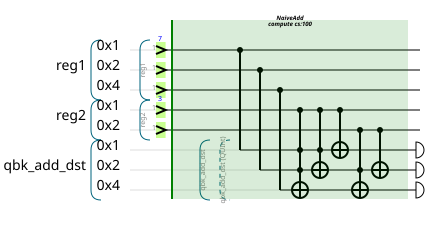

In [3]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import NaiveAdd

qpu = QPU(num_qubits=8)
reg1, reg2 = QUInt(3, "reg1", qpu), QUInt(2, "reg2", qpu)

reg1.write(7)
reg2.write(3)

# Use naive adder to add two unsigned integers out-of-place
naive_add = NaiveAdd()
naive_add.compute(reg1, reg2, alloc_result=True)
result = naive_add.get_result_qreg()
print(f"7 + 3 = {result.read()} (mod 8)")

qpu.draw(show_qubricks=True)

### Addition of different data types

Finally, you can use the same Qubricks to perform addition on different data types. Same as when adding a classical number to a quantum one, the syntax is going to be the same; under the hood, the Qubrick analyzes the types of the input registers and chooses the type-appropriate implementation of addition.

The following code snippet shows naive addition circuits for unsigned and signed quantum integers (`QUInt` and `QInt`, respectively). You can see that the circuits are different: the extra gates in the end of the second (signed) circuit, controlled on the sign bit of the bottom register, perform sign extension - the "virtual" increase in the number of bits in the shorter integer to match the number of bits in the longer one. This step is not necessary when the shorter integer is unsigned, since its sign bit is guaranteed to be $0$.

4 + 5 = 9
4 + (-3) = 1


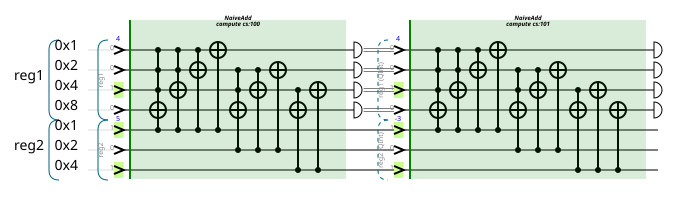

In [4]:
from psiqdk.workbench import QInt, QPU, QUInt

qpu = QPU(num_qubits=7)
reg1, reg2 = QUInt(4, "reg1", qpu), QUInt(3, "reg2", qpu)
reg1.write(4)
reg2.write(5)
reg1 += reg2
print(f"4 + 5 = {reg1.read()}")

reg1, reg2 = QInt(reg1), QInt(reg2)
reg1.write(4)
reg2.write(-3)
reg1 += reg2
print(f"4 + (-3) = {reg1.read()}")

qpu.draw(show_qubricks=True)

Similarly, the following example shows naive addition circuits for unsigned and signed fixed-point numbers (`QUFixed` and `QFixed`, respectively) with different radixes. You can see the same extra gates that perform sign extension in the second (signed) circuit. Additionally, you can see that the circuits are slightly different from the ones used for integer addition: the fixed-point registers are aligned by the separation between the integer and the fractional parts, not by the least significant bit overall like the integer registers.

1.25 + 2.5 = 3.75
1.25 + (-1.5) = -0.25


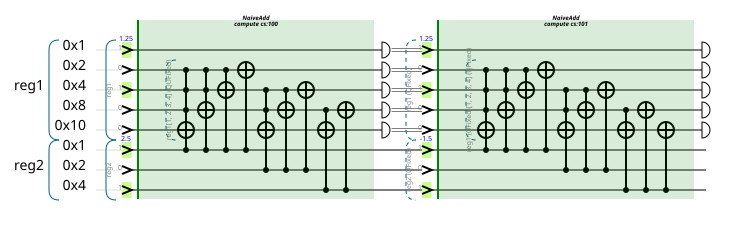

In [5]:
from psiqdk.workbench import QFixed, QPU, QUFixed

qpu = QPU(num_qubits=8)
reg1, reg2 = QUFixed(5, 2, "reg1", qpu), QUFixed(3, 1, "reg2", qpu)
reg1.write(1.25)
reg2.write(2.5)
reg1 += reg2
print(f"1.25 + 2.5 = {reg1.read()}")

reg1, reg2 = QFixed(reg1), QFixed(reg2)
reg1.write(1.25)
reg2.write(-1.5)
reg1 += reg2
print(f"1.25 + (-1.5) = {reg1.read()}")

qpu.draw(show_qubricks=True)

## Subtraction

Workbench does not have dedicated "subtractor" Qubricks. Instead, subtraction is done by the same `NaiveAdd`, `GidneyAdd`, `CuccaroAdd` and `CuccaroDepthOptimisedAdd` Qubricks if you pass an extra argument `subtract_condition=True` to the `compute` method. Same as for addition, Workbench offers syntactic sugar `reg1 -= reg2` for in-place naive subtraction. Subtraction shares all properties of addition that we discussed earlier in the tutorial.

The following example shows using naive, Gidney and Cuccaro adders to perform in-place subtraction. Notice that subtraction is modular as well so second subtraction $1 - 3$ yields result $6$ and the final subtraction yields $6 - 3 = 3$.

4 - 3 = 1
1 - 3 = 6 (mod 8)
6 - 3 = 3 (mod 8)


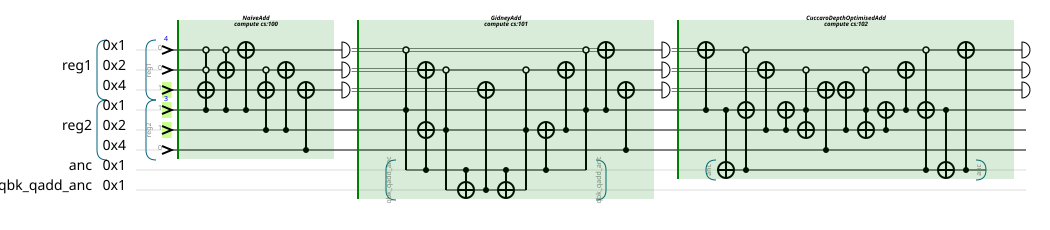

In [6]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import CuccaroDepthOptimisedAdd, GidneyAdd, NaiveAdd

qpu = QPU(num_qubits=8)
reg1, reg2 = QUInt(3, "reg1", qpu), QUInt(3, "reg2", qpu)

reg1.write(4)
reg2.write(3)

# Use naive adder to subtract two unsigned integers in-place
reg1 -= reg2
# The line above is equivalent to the following two lines:
# naive_add = NaiveAdd()
# naive_add.compute(reg1, reg2, subtract_condition=True)

print(f"4 - 3 = {reg1.read()}")

# Use Gidney adder to subtract two unsigned integers in-place
gidney_add = GidneyAdd()
gidney_add.compute(reg1, reg2, subtract_condition=True)

print(f"1 - 3 = {reg1.read()} (mod 8)")

# Use Cuccaro adder to subtract two unsigned integers in-place
cuccaro_add = CuccaroDepthOptimisedAdd()
cuccaro_add.compute(reg1, reg2, subtract_condition=True)

print(f"6 - 3 = {reg1.read()} (mod 8)")

qpu.draw(show_qubricks=True)

## Multiplication

Quantum multiplication is the operation of multiplying two compatible numbers. Workbench implements multiplication as "multiply-and-add", that is, an out-of-place operation that adds a product of two factors passed as arguments to the third argument, the destination. There is no in-place version of multiplication; if the destination register is not provided, the Qubrick allocates a fresh register and returns it as the result.

The following code snippet shows how to perform multiplication using `NaiveMultiplyAdd`, `GidneyMultiplyAdd` and `CuccaroMultiplyAdd` Qubricks. 

> Notice that the destination register is the first positional argument of the `compute` method for these Qubricks, and it is a required argument. If you want the Qubrick to allocate the result register, you have to pass `None` as the first argument to the `compute` method explicitly, as shown for the `naive_madd` Qubrick.

2 * 3 = 6
6 + 2 * 3 = 12 (mod 16)
12 + 2 * 3 = 2 (mod 16)


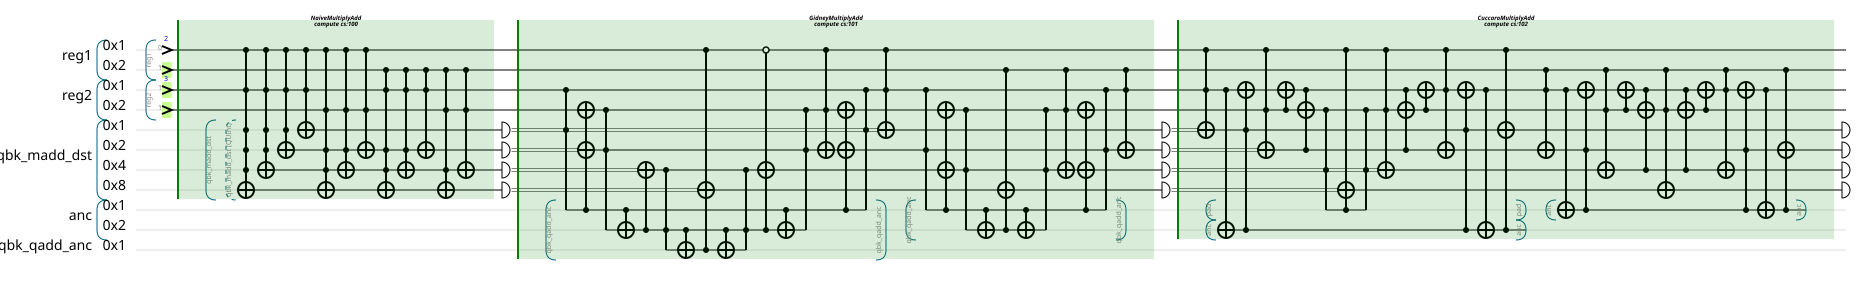

In [7]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.arithmetic import CuccaroMultiplyAdd, GidneyMultiplyAdd, NaiveMultiplyAdd

qpu = QPU(num_qubits=11)
reg1, reg2 = QUInt(2, "reg1", qpu), QUInt(2, "reg2", qpu)

reg1.write(2)
reg2.write(3)

# Use naive MultiplyAdd to multiply two unsigned integers out-of-place
# (have the Qubrick allocate the result register)
naive_madd = NaiveMultiplyAdd()
naive_madd.compute(None, reg1, reg2)
dest = naive_madd.get_result_qreg()
print(f"2 * 3 = {dest.read()}")

# Use Gidney MultiplyAdd to multiply two unsigned integers out-of-place
# (add the result to the result register from the previous multiplication)
gidney_madd = GidneyMultiplyAdd()
gidney_madd.compute(dest, reg1, reg2)
# 4 qubits in dest so result will be mod 16
print(f"6 + 2 * 3 = {dest.read()} (mod 16)") 

# Use Cuccaro MultiplyAdd to multiply two unsigned integers out-of-place
# (add the result to the result register from the previous multiplication)
cuccaro_madd = CuccaroMultiplyAdd()
cuccaro_madd.compute(dest, reg1, reg2)
# 4 qubits in dest so result will be mod 16
print(f"12 + 2 * 3 = {dest.read()} (mod 16)")

qpu.draw(show_qubricks=True)

## Square

Squaring a quantum number is a logical extension of multiplication. It is implemented as `NaiveSquare` and `GidneySquare` Qubricks. Same as multiplication, it acts out-of-place.

The following example shows how to square a quantum register of type `QUFixed` using the `NaiveSquare` Qubrick.

2.5² = 6.25


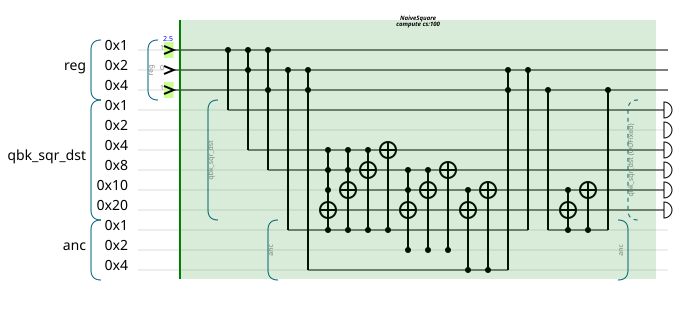

In [8]:
from psiqdk.workbench import QPU, QUFixed
from psiqdk.workbench.arithmetic import NaiveSquare

qpu = QPU(num_qubits=12)
reg = QUFixed(3, 1, "reg", qpu)

reg.write(2.5)

# Use NaiveSquare to square an unsigned fixed-point number out-of-place
# (have the Qubrick allocate the result register)
naive_square = NaiveSquare()
naive_square.compute(reg)
dest = naive_square.get_result_qreg()
print(f"2.5² = {dest.read()}")

qpu.draw(show_qubricks=True)

## Bitwise operations

Workbench supports two bitwise arithmetic operations: bitwise negation (`CondInvert`) and bitwise XOR (`CondXor`). 

Bitwise negation flips every qubit of the input register. 
We have seen it in action earlier, when we discussed controlled gates: `~reg`, the negation of the register `reg`, is the result of applying bitwise negation to a register using syntactic sugar.

Bitwise XOR computes XOR of matching pairs of qubits in-place, storing the result in the first argument.

The following example shows how to use bitwise negation and XOR in a program.

> Notice that bitwise negation is implemented by modifying the `cond_xor` mask of the register rather than by applying gates to it; its effects don't show up on diagrams but affect measurement outcomes and gates applied later in the circuit. For example, you can see that the gates applied by `CondXor` Qubrick are controlled on zero instead of regular controlled gates used to compute XOR of two registers. This reflects the fact that the second argument of `CondXor` is negated, so control patterns of gates that use its qubits as controls have to be inverted.

~2 = 1
~2 XOR 3 = 2


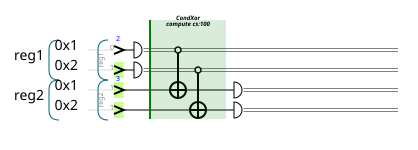

In [9]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.comparators import CondXor

qpu = QPU(num_qubits=4)
reg1, reg2 = QUInt(2, "reg1", qpu), QUInt(2, "reg2", qpu)

reg1.write(2)
reg2.write(3)

# Negate register reg1
reg1 = ~reg1
print(f"~2 = {reg1.read()}")

xor = CondXor()
xor.compute(reg2, reg1)
print(f"~2 XOR 3 = {reg2.read()}")

qpu.nop(repeat=8)
qpu.draw(show_qubricks=True)

## Comparison

Comparison of two numbers is sometimes considered together with arithmetic operations, so we will briefly mention it here. 

In Workbench, the Qubricks implementing comparisons follow a somewhat different pattern compared to the arithmetic Qubricks.
They always perform comparisons out-of-place, allocating a single-qubit register which encodes the Boolean value of the comparison outcome ($1$ for True, $0$ for False) and returning it as a result of the `compute` method.

The following table lists Workbench comparators and the Qubricks that implement them.
| Comparison | Qubrick |
| ---------- | ------- |
| `==` | `CompareEQ` |
| `!=` | `CompareNE` |
| `<` | `CompareLT` |
| `>` | `CompareGT` |
| `<=` | `CompareLE` |
| `>=` | `CompareGE` |

Comparison Qubricks other than equality and inequality use Gidney comparisons.

Workbench comparators are most commonly used via a combination of syntactic sugar that replaces a `compute` call with an expression such as `a > b` and a context manager that handles the `compute` call, getting the register with the result of the `compute` call, and uncompute. We will revisit using comparators in the next tutorial in which we discuss this pattern.

The following code example shows an example of using a comparison Qubrick explicitly.

2 > 3 = False
2 < 3 = True


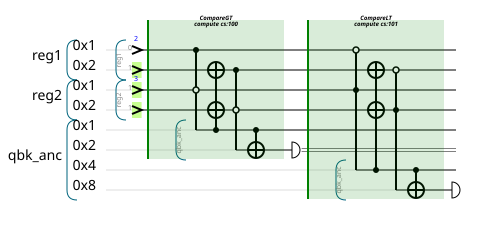

In [10]:
from psiqdk.workbench import QPU, QUInt
from psiqdk.workbench.comparators import CompareGT, CompareLT

qpu = QPU(num_qubits=8)
reg1, reg2 = QUInt(2, "reg1", qpu), QUInt(2, "reg2", qpu)

reg1.write(2)
reg2.write(3)

# Use CompareGT and CompareLT Qubricks to check 
# whether reg1 is greater than or less than reg2
gt = CompareGT()
gt.compute(reg1, reg2)
gt_dest = gt.get_result_qreg()
print(f"2 > 3 = {bool(gt_dest.read())}")

lt = CompareLT()
lt.compute(reg1, reg2)
lt_dest = lt.get_result_qreg()
print(f"2 < 3 = {bool(lt_dest.read())}")

qpu.draw(show_qubricks=True)

## Overloading arithmetic operators

Some Qubricks we saw in this tutorial have shorthand operators defined for them: for example, you can write `reg1 += reg2` instead of instantiating `NaiveAdd` and calling its `compute` method, or `~reg` instead of instantiating `CondInvert` and calling its `compute` method. (Comparison Qubricks also have matching operators, as we'll see in the [next tutorial](./Qubricks-Computed-Context-Manager.ipynb).)

If you want to redefine one of these operators to call a different Qubrick - for example, `GidneyAdd` or your own adder implementation instead of `NaiveAdd` - you can do that using the method `set_qubit_logic_operator` of a QPU object:

```python
qpu.set_qubit_logic_operator("+=", GidneyAdd)
```


## Next steps

In this tutorial, you've learned how to use quantum arithmetic in Workbench. In the next tutorial, we will explore other [built-in Qubricks](./Built-in-Qubricks.ipynb) provided by Workbench. Alternatively, you can learn about [using a context manager to perform sequences of quantum operations](./Qubricks-Computed-Context-Manager.ipynb), including uncomputation of intermediate results, that is commonly used with arithmetic operations, especially comparators.